In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [68]:
x,y=make_regression(n_samples=100,
                    n_features=1,
                    n_informative=1,
                    n_targets=1,
                    noise=20,
                    random_state=2)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

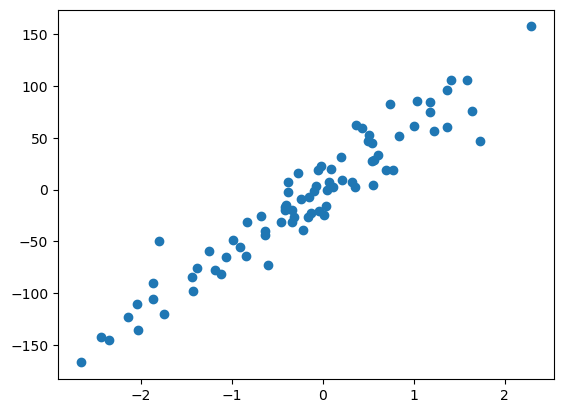

In [69]:
plt.scatter(x_train,y_train)

GD_regression using sklearn

In [70]:
from sklearn.linear_model import LinearRegression

In [71]:
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
m=lr.coef_
print('coeff:',m)
print('intercept:',lr.intercept_)

coeff: [58.85092863]
intercept: 1.4587736173147157


In [72]:
#Calculating r2 score for sklearn Linear regression:
r2=r2_score(y_test,y_pred)
r2

0.8723215560499293

In [73]:
class GD_regressor:
    def __init__(self,learn_rate,epochs):
        self.m=100
        self.b=-120
        self.lr=learn_rate
        self.epochs=epochs
    
    def fit(self,x,y):
        for i in range(self.epochs):
            #loss slope for m and b
            loss_slope_b= -2* np.sum(y-self.m *x.ravel()-self.b)
            loss_slope_m= -2* np.sum((y-self.m *x.ravel()-self.b)*x.ravel())
            
            #step size for both m and b
            step_size_b=self.lr*loss_slope_b
            step_size_m=self.lr*loss_slope_m
            
            # Finding values of m and b:
            self.b=self.b-step_size_b
            self.m=self.m-step_size_m
        print('intercept:',self.b)
        print('slope:',self.m)
        
    def predict(self,x):
        return self.m*x+self.b

In [76]:
gd=GD_regressor(0.001,50)
gd.fit(x_train,y_train)
y_pred=gd.predict(x_test)

intercept: 1.4247089558186807
slope: 58.82994668946077


In [78]:
#Calculating r2 score for sklearn Linear regression:
r2=r2_score(y_test,y_pred)
r2

0.8724901969687482